# 03D - Time Trends & Executive Insights

Analyze temporal patterns and summarize business insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(10,5)
df=pd.read_csv(r"/mnt/data/american_bankruptcy.csv")


## Records by Year

,Records
year,
1999,5308
2000,5226
2001,4897
2002,4651
2003,4417
2004,4348
2005,4205
2006,4128
2007,4009


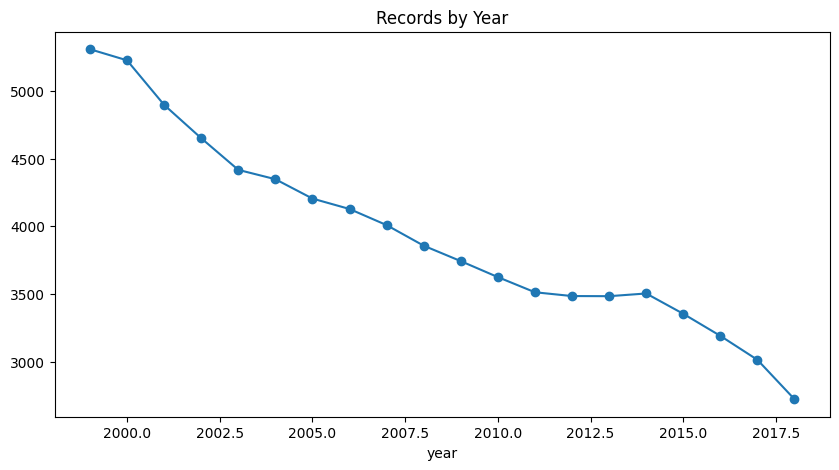

In [2]:
year_counts=df.groupby('year').size()
display(year_counts.to_frame('Records'))
year_counts.plot(marker='o',title='Records by Year')
plt.show()

## Bankruptcy Trend

status_label,alive,failed
year,,
1999,4928,380
2000,4822,404
2001,4483,414
2002,4237,414
2003,4002,415
2004,3944,404
2005,3826,379
2006,3762,366
2007,3673,336


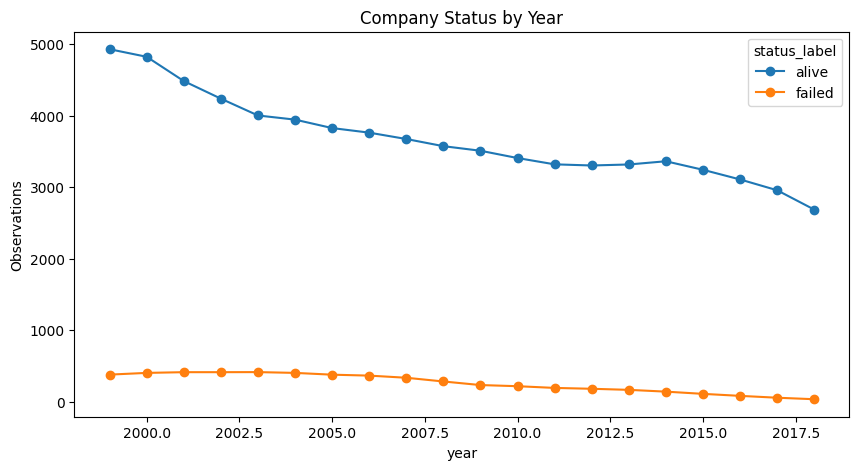

In [3]:
trend=df.groupby(['year','status_label']).size().unstack(fill_value=0)
display(trend)
trend.plot(marker='o',title='Company Status by Year')
plt.ylabel('Observations')
plt.show()

## Bankruptcy Rate by Year

status_label,alive,failed
year,,
1999,92.84,7.16
2000,92.27,7.73
2001,91.55,8.45
2002,91.10,8.90
2003,90.60,9.40
2004,90.71,9.29
2005,90.99,9.01
2006,91.13,8.87
2007,91.62,8.38


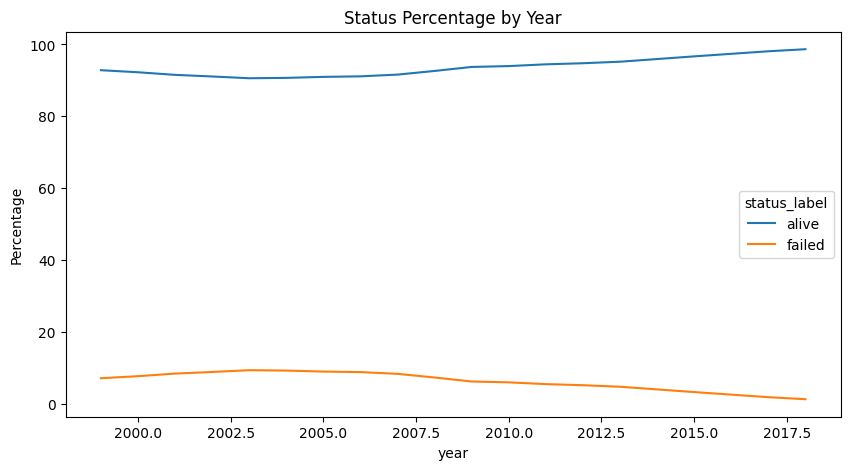

In [4]:
rate=trend.div(trend.sum(axis=1),axis=0)*100
display(rate.round(2))
rate.plot(title='Status Percentage by Year')
plt.ylabel('Percentage')
plt.show()

## Company Observation Analysis

In [5]:
obs=df.groupby('company_name').size().sort_values(ascending=False)
display(obs.head(20).to_frame('Observations'))
obs.describe()

,Observations
company_name,
C_956,20
C_1012,20
C_999,20
C_969,20
C_10,20
C_966,20
C_1000,20
C_1001,20
C_1002,20


count    8971.000000
mean        8.770706
std         6.421565
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        20.000000
dtype: float64

## Top Reporting Companies

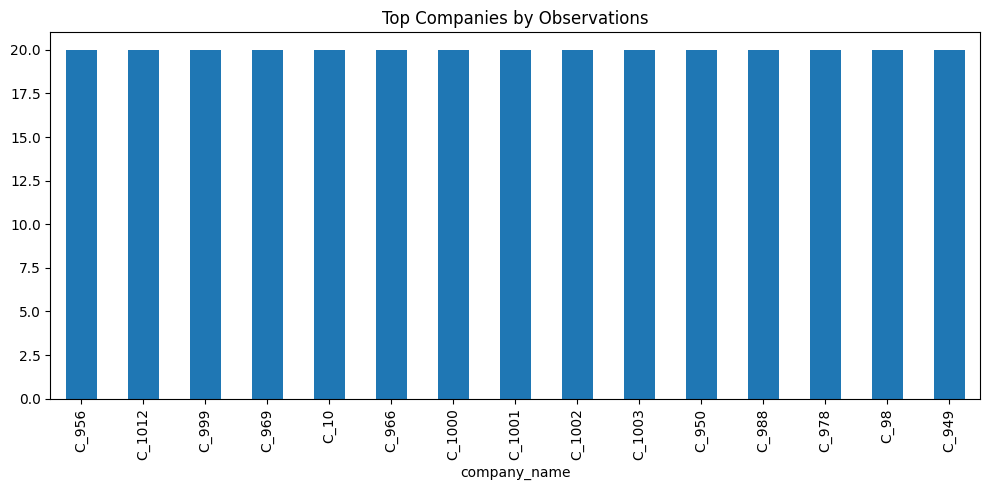

In [6]:
obs.head(15).plot(kind='bar',title='Top Companies by Observations')
plt.tight_layout()
plt.show()

## Executive Summary Metrics

In [7]:
summary=pd.DataFrame({
'Metric':['Rows','Companies','Years','Alive','Failed'],
'Value':[
len(df),
df['company_name'].nunique(),
f"{df['year'].min()}-{df['year'].max()}",
(df['status_label']=='alive').sum(),
(df['status_label']!='alive').sum()
]})
display(summary)

,Metric,Value
0,Rows,78682
1,Companies,8971
2,Years,1999-2018
3,Alive,73462
4,Failed,5220


## Business Insights

In [8]:
insights=[
'Historical coverage supports trend analysis across multiple fiscal years.',
'The dataset is imbalanced, so evaluation metrics beyond accuracy are required.',
'Time-based validation should be considered to avoid data leakage.',
'Company history length varies and may influence longitudinal analysis.',
'Outliers and correlated variables identified earlier should guide preprocessing.'
]
for i,txt in enumerate(insights,1):
    print(f'{i}. {txt}')

1. Historical coverage supports trend analysis across multiple fiscal years.
2. The dataset is imbalanced, so evaluation metrics beyond accuracy are required.
3. Time-based validation should be considered to avoid data leakage.
4. Company history length varies and may influence longitudinal analysis.
5. Outliers and correlated variables identified earlier should guide preprocessing.


## Recommendations for Phase 2

In [9]:
recs=[
'Encode target labels.',
'Handle class imbalance.',
'Scale or transform skewed variables where appropriate.',
'Perform feature engineering.',
'Prepare train, validation and test datasets.'
]
for r in recs:
    print('-',r)

- Encode target labels.
- Handle class imbalance.
- Scale or transform skewed variables where appropriate.
- Perform feature engineering.
- Prepare train, validation and test datasets.
